In [ ]:
import pandas as pd
import numpy as np
from scipy.stats import entropy
from scipy import signal
from statsmodels.tsa import tsatools, seasonal
from collections import defaultdict
import os, sys
from tqdm import tqdm
from typing import Literal
from meegkit.detrend import detrend as meeg_detrend, regress
from sklearn.decomposition import FastICA

import matplotlib.pyplot as plt

In [ ]:
os.chdir(r'J:\Onderzoek\21-763_rvanes_MiniECG-2-Data\E_ResearchData\2_ResearchData\numpy\numpy')

In [117]:
FACTOR = 1e-3
NUM_ICA_COMPONENTS = 4

In [ ]:
np.arange(0,10,1)

In [ ]:
def DeTrender(ts: np.ndarray,
              how: Literal=['poly', 'MSTL', 'meeg'],
              order=1, 
              period=100, 
              windows=101, 
              cutsize=250,
              median_window=25,
              iterate=5):
    if how == 'poly':
        return tsatools.detrend(ts, order=order)
    elif how == 'poly_np':
        z = np.polyfit(np.arange(0,ts.shape[0],1), ts, order)
        y_poly = np.poly1d(z)
        return ts-y_poly(np.arange(0,ts.shape[0],1))
    elif how == 'MSTL':
        detrender= seasonal.MSTL(ts, periods=period, windows=windows, iterate=iterate).fit()
        return detrender.seasonal
    elif how == 'meeg':
        '''
         Use sinusoids as basis functions:
          This will suffer from the Gibbs-phenomenon. 
          To mitigate this, we have to cut the head/tail
        '''
        _ts = np.array(ts).astype(float)
        return meeg_detrend(_ts, order=order, basis="sinusoids")[0][cutsize:-cutsize] 
    elif how == 'sliding_median':
        '''
         Make base plot using sliding mean, subtract from raw 
        '''
        sl= np.median(np.lib.stride_tricks.sliding_window_view(ts, (median_window,)), axis=1)
        return ts[median_window-1:] - sl
    else:
        raise ValueError(f"For now we only accept ['poly', 'MSTL', 'meeg]")
    
def HighPassFilter(ts):
    pass

def LowPassFilter(ts):
    pass

class ButterworthBandpassFilter:
    def __init__(self, lowcut, highcut, fs, order=5):
        self.lowcut = lowcut
        self.highcut = highcut
        self.fs = fs
        self.order = order
        self.b, self.a = self._design_filter()

    def _design_filter(self):
        nyq = 0.5 * self.fs
        low = self.lowcut / nyq
        high = self.highcut / nyq
        return signal.butter(self.order, [low, high], btype='band')

    def apply_filter(self, data):
        return signal.lfilter(self.b, self.a, data)

class ICASignalSeparator:
    def __init__(self, n_components=None, max_iter=250):
        self.n_components = n_components
        self.ica = FastICA(n_components=n_components, random_state=42, max_iter=max_iter)
        
    def separate(self, mixed_signals):
        """
        Separate mixed signals using ICA.
        
        :param mixed_signals: 2D array, shape (n_samples, n_features)
        :return: 2D array of separated signals
        """
        return self.ica.fit_transform(mixed_signals.T).T
    
    def plot_signals(self, original_signals, mixed_signals, separated_signals):
        n_signals = original_signals.shape[0]
        time = np.linspace(0, 10, original_signals.shape[1])
        
        fig, axs = plt.subplots(3, n_signals, figsize=(15, 10))
        fig.suptitle('Original, Mixed, and Separated Signals')
        
        for i in range(n_signals):
            axs[0, i].plot(time, original_signals[i])
            axs[0, i].set_title(f'Original Signal {i+1}')
            
            axs[1, i].plot(time, mixed_signals[i])
            axs[1, i].set_title(f'Mixed Signal {i+1}')
            
            axs[2, i].plot(time, separated_signals[i])
            axs[2, i].set_title(f'Separated Signal {i+1}')
        
        for ax in axs.flat:
            ax.set(xlabel='Time', ylabel='Amplitude')
        
        plt.tight_layout()
        plt.show()


'''
Ideally we have a signal-processing pipe that maximally consists of 
ts -> Interpolator -> SignalSeparator -> DeTrender -> HighPassFilter -> LowPassFilter

'''

In [ ]:
# LOAD IN ALL THE NPYs
DIRS = os.listdir('.')
ECG_DICT = defaultdict(list)
SKIPPED = []
for DIR in tqdm(DIRS):
    for FILE in os.listdir(DIR):
        if FILE.endswith('.npy'):
            arr = np.load(os.path.join(DIR, FILE))
            vars = np.var(arr, axis=1)
            if any(vars == 0) == False:
                ECG_DICT[DIR].append(arr)
            else:
                SKIPPED.append(f"{DIR}/{FILE}")

In [ ]:
c = 0
for k,v in ECG_DICT.items():
    c += len(v)
print(f"We kept {c} ECG results, skipping {len(SKIPPED)} because they had at least one flat band")

# Get Spectrograms

In [ ]:
raw = ECG_DICT['20230720'][0]*FACTOR

In [ ]:
separator = ICASignalSeparator(n_components=NUM_ICA_COMPONENTS, max_iter=1000)
separated = separator.separate(raw)

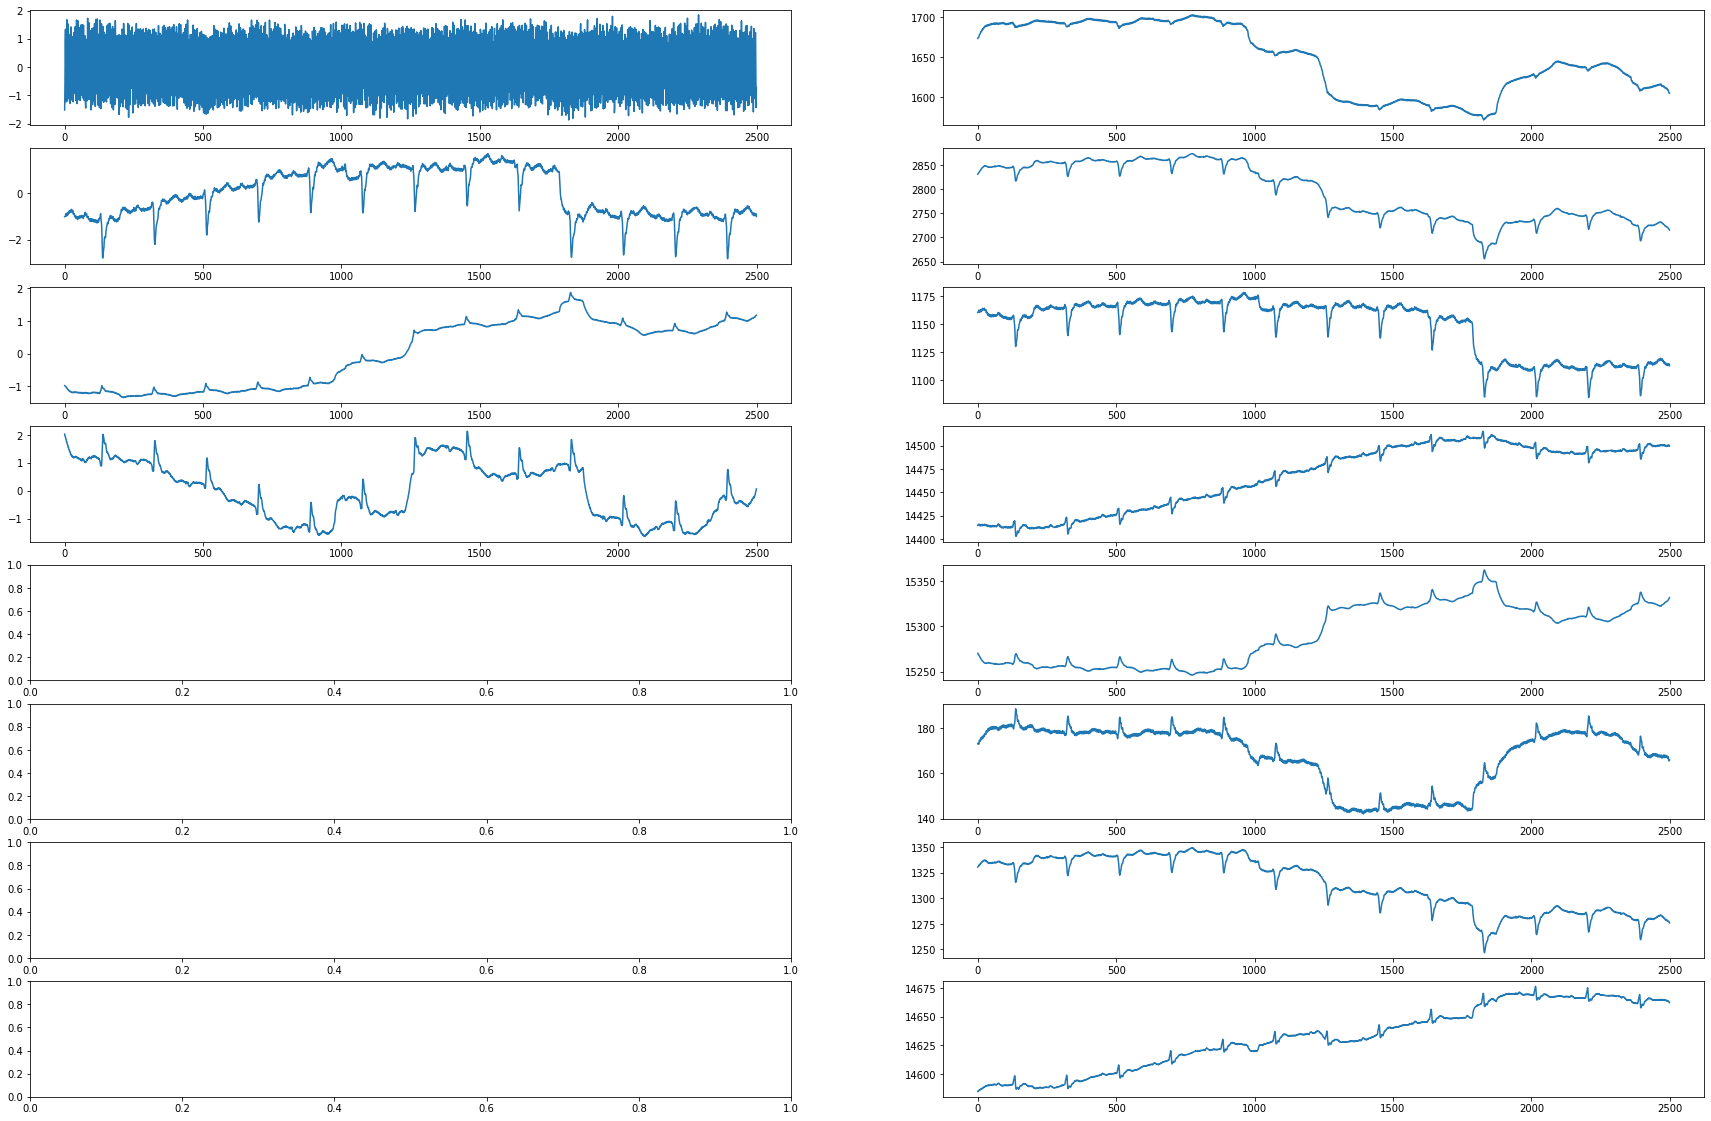

In [118]:
fig, ax = plt.subplots(nrows=8, ncols=2, figsize=(30,20))

for i in range(0, NUM_ICA_COMPONENTS):
    ax[i,0].plot(separated[i])

ax[0,1].plot(raw[0])
ax[1,1].plot(raw[1])
ax[2,1].plot(raw[2])
ax[3,1].plot(raw[3])
ax[4,1].plot(raw[4])
ax[5,1].plot(raw[5])
ax[6,1].plot(raw[6])
ax[7,1].plot(raw[7])

In [ ]:
detrended = DeTrender(raw, how='sliding_median', order=24, cutsize=250)
banded = ButterworthBandpassFilter(0.5,50, 250, order=5).apply_filter(detrended)

In [ ]:
fig, ax = plt.subplots(figsize=(18,8), ncols=1)
ax.plot(detrended)
ax.plot(banded, alpha=0.45)

For an ECG feature extractor it makes sense to use **multiple** bandpass filters, **multiple** detrending methods and **multiple** ICAs.

# Fourier coefficients

# Peak/valley characteristics